### Project on Algorithmic Bias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("mortgage_covenant_data.csv")

df.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

,activity_year,census_tract,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count
count,100931.0,9.991500e+04,100931.000000,1.009310e+05,8.349100e+04,8.820000e+04,78125.000000,100931.000000,100931.000000,100931.000000,100931.000000
mean,2023.0,2.708025e+10,2.309528,3.110060e+05,3.987726e+05,1.489660e+02,6.575084,22.874029,101.813583,48.624763,17.408101
std,0.0,5.254319e+07,1.950185,7.617088e+05,1.197102e+06,5.568826e+03,1.273054,17.292952,32.381060,203.617075,84.973673
min,2023.0,2.700177e+10,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2023.0,2.703706e+10,1.000000,1.750000e+05,2.350000e+05,6.700000e+01,6.125000,10.140000,82.070000,10.000000,0.000000
50%,2023.0,2.705311e+10,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.640000,99.060000,10.000000,0.000000
75%,2023.0,2.712304e+10,4.000000,3.650000e+05,4.350000e+05,1.460000e+02,7.125000,29.710000,119.950000,10.000000,0.000000
max,2023.0,2.717397e+10,8.000000,5.700500e+07,1.113250e+08,1.651000e+06,15.500000,95.630000,240.430000,1111.000000,965.000000


# Analysis for Data Bias.

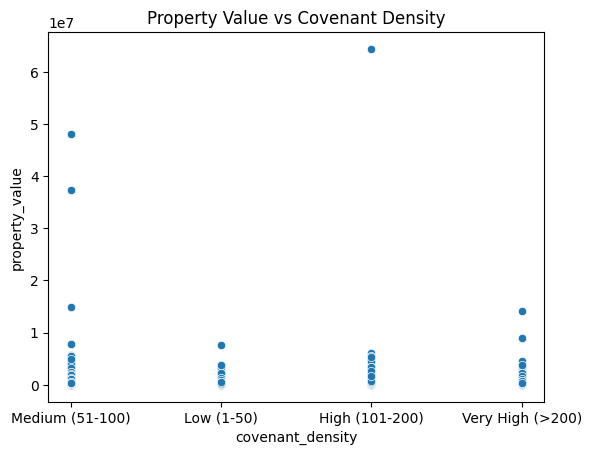

In [ ]:
# Property Value vs Covenant Density
sns.scatterplot(x="covenant_density", y="property_value", data=df)
plt.title("Property Value vs Covenant Density")
plt.show()

This scatter plot shows the relationship between covenant_density and property_value. The x-axis represents covenant density categories (Low, Medium, High, Very High), while the y-axis shows property values for individual properties. The wide variation in property values across these categories telling that historical housing discrimination may still influence modern housing prices.

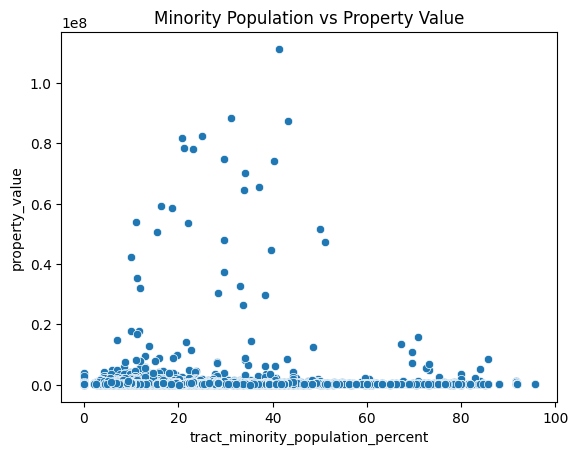

In [ ]:
# Minority Population Analysis
sns.scatterplot(x="tract_minority_population_percent", y="property_value", data=df)
plt.title("Minority Population vs Property Value")
plt.show()


This scatter plot shows the relationship between tract_minority_population_percent and property_value.
Higher property values (up to about $110M) appear mostly in areas where the minority population is around 20–40%, while areas with very high minority population percentages generally show lower property values.
This pattern suggests that neighborhood demographics may still be associated with differences in housing market values.

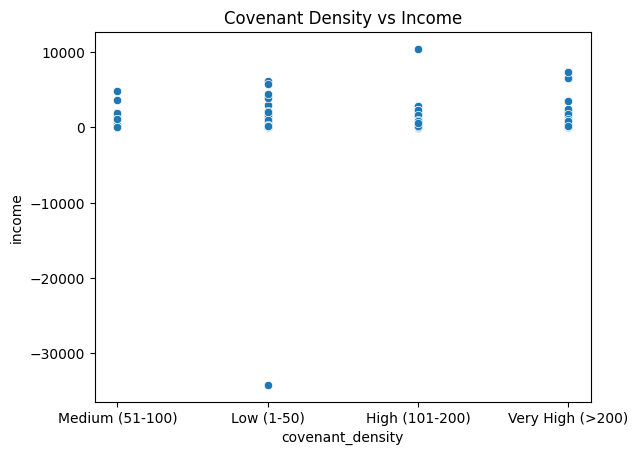

In [ ]:
# Covenant Density vs Neighborhood Income
sns.scatterplot(x="covenant_density", y="income", data=df)
plt.title("Covenant Density vs Income")
plt.show()

This scatter plot shows the relationship between covenant_density and applicant income levels. Most income values range between approximately 0 and 6,000 across all covenant density groups, with a few higher values reaching around $10,000. The presence of income variation across these categories tells that neighborhoods with different histories of housing discrimination may show differences in economic characteristics.

#### Analyasis for Algorthmic Bias

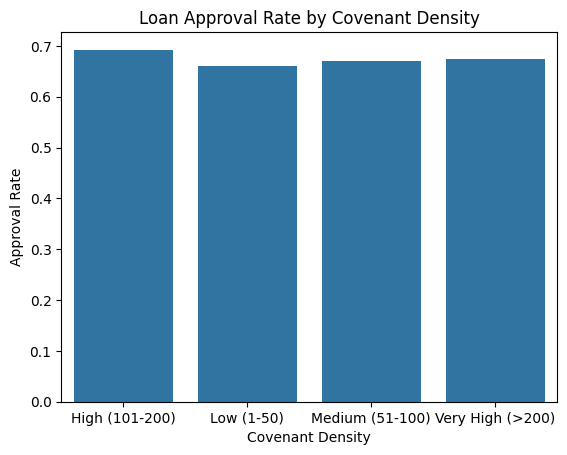

In [ ]:
approval_rate = df.groupby("covenant_density")["was_approved"].mean().reset_index()

sns.barplot(x="covenant_density", y="was_approved", data=approval_rate)

plt.title("Loan Approval Rate by Covenant Density")
plt.xlabel("Covenant Density")
plt.ylabel("Approval Rate")
plt.show()

This bar chart shows the loan approval rate across different covenant_density categories.
Approval rates range from approximately 66% to 69%, indicating only a small difference between neighborhoods with different covenant density levels.
This suggests that mortgage approval outcomes appear relatively consistent across these areas, although further analysis may still be needed to examine potential algorithmic bias.

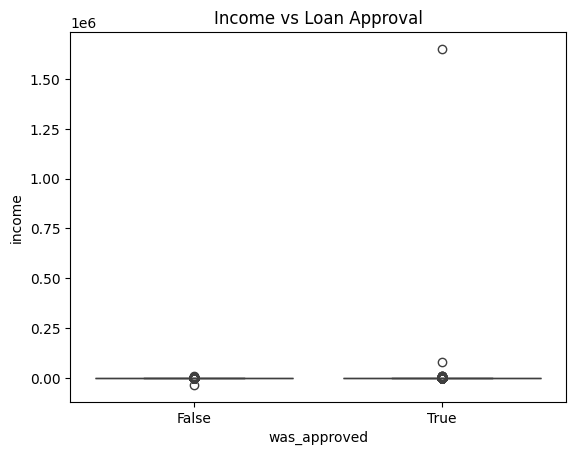

In [ ]:
# Income vs Loan Approval
sns.boxplot(x="was_approved", y="income", data=df)
plt.title("Income vs Loan Approval")
plt.show()

This plot compares applicant income levels for approved and denied mortgage applications.
Most incomes fall below approximately $100,000, while a few approved applicants have very high incomes, reaching around 1.6 million.
This pattern suggests that higher income levels may increase the likelihood of mortgage approval, indicating income may act as a key factor in lending decisions.

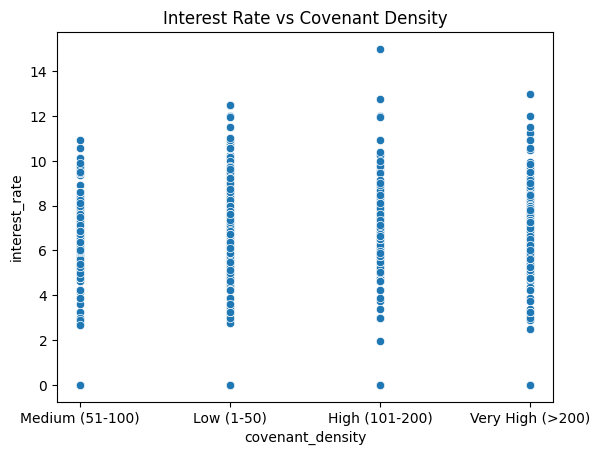

In [ ]:
#Interest Rate vs Covenant Density
sns.scatterplot(x="covenant_density", y="interest_rate", data=df)
plt.title("Interest Rate vs Covenant Density")
plt.show()

This scatter plot shows the relationship between covenant_density and mortgage interest rates.
Most interest rates fall between approximately 4% and 10% across all covenant density categories, with some higher values reaching about 15%.
The similar distribution of interest rates across these groups suggests that lending terms do not vary strongly by covenant density, although some variation still exists.

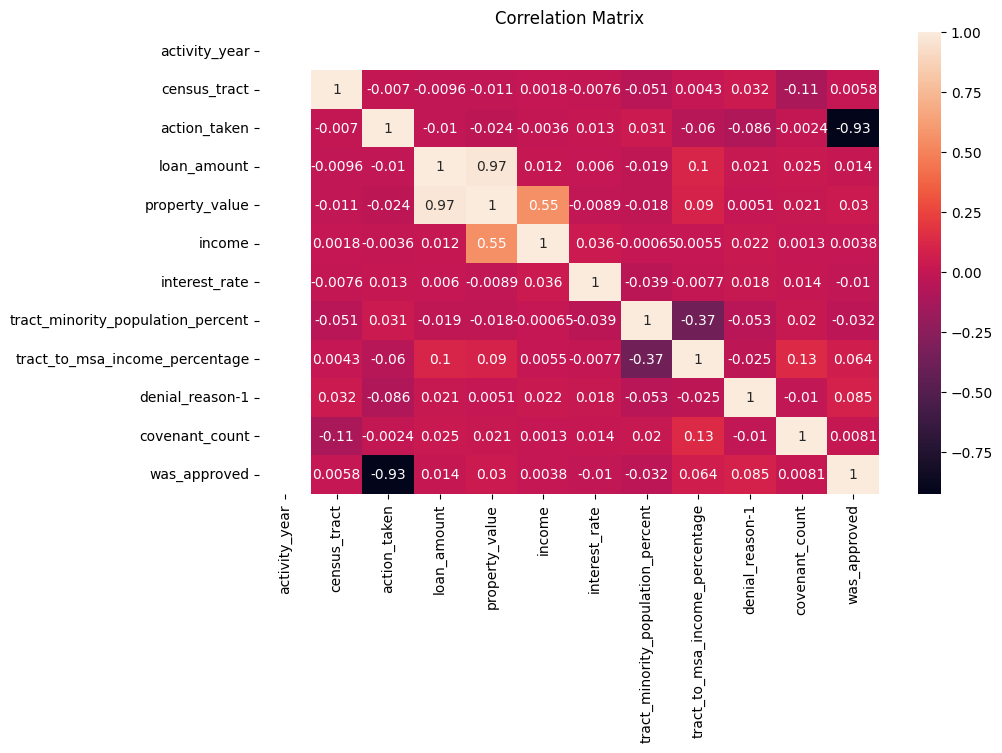

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

This correlation heatmap shows the relationships between key numerical variables in the dataset. A strong positive correlation exists between loan_amount and property_value (0.97), while income shows a moderate relationship with property values (0.55). Additionally, a negative correlation (-0.37) between minority population percentage and neighborhood income suggests potential economic disparities across different communities.